# Compression d’images avec NumPy
Ce notebook s’appuie sur le tutoriel suivant : https://github.com/numpy/numpy-tutorials/blob/main/content/tutorial-svd.md.

L’objectif est de compresser une image en appliquant la Décomposition en Valeurs Singulières (SVD) aux matrices de ses canaux RGB, l’image étant représentée par un tableau de dimensions (hauteur×largeur×3).

In [79]:
import numpy as np
import matplotlib.pyplot as plt
import PIL
import skimage

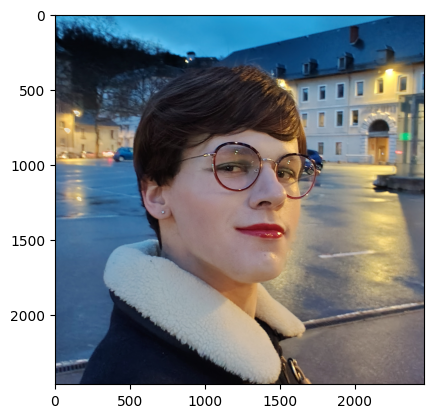

In [80]:
img = PIL.Image.open("face.jpg")

fig, ax = plt.subplots()
ax.imshow(img)

Nous convertissons les valeurs RGB, comprises entre 0 et 255, en flottants (float32) entre 0 et 1 afin d’appliquer la SVD.

In [81]:
img_array = skimage.util.img_as_float32(img) # Que des nombres réels
print(np.all(img_array >= 0) & np.all(img_array <= 1))
print(img_array.dtype)

True
float32


Nous pouvons maintenant utiliser une formule type afin d’obtenir une image en niveaux de gris.

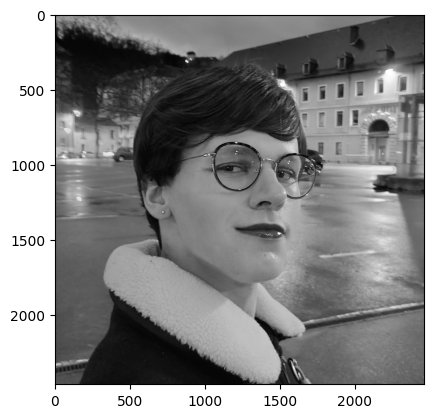

In [82]:
# RGB : 0 red, 1 green, 2 blue

red_array = img_array[:, :, 0]
green_array = img_array[:, :, 1]
blue_array = img_array[:, :, 2]

img_gray = img_array @ [0.2126, 0.7152, 0.0722]

fig, ax = plt.subplots()
ax.imshow(img_gray, cmap="gray")

Nous utilisons la fonction de numpy pour effectuer une décomposition en valeurs singulière de l’image avec l’algorithme de numpy.

In [83]:
U, s, Vt = np.linalg.svd(img_gray, full_matrices=False) # L’option full_matrices n’est pas pertinent pour les matrices carrées

In [84]:
print(U.shape)
print(s.shape)
print(Vt.shape)

(2464, 2464)
(2464,)
(2464, 2464)


Nous obtetons s sous la forme d’une matrice en 1 dimension (pour des raisons d’économie de place en mémoire). Il nous faut la transformer avant de pouvoir la multiplier à U et Vt.

In [85]:
Sigma = np.diag(s)
print(Sigma.shape)

(2464, 2464)


À quelques erreurs d’approximation près, la multiplication de ces trois matrices et l’image initiale sont identiques.

In [86]:
print(np.allclose(U @ Sigma @ Vt, img_gray, rtol=1e-5, atol=1e-8))

# Si la norme de leur différences est très petite, cela signifie que les deux matrices sont très similaires :
print(np.linalg.norm(img_gray - U @ Sigma @ Vt)) 

True
8.640003757537781e-12


Nous allons maintenant compresser l’image et obtenir une approximation. Nous n’allons garder que les k premières valeurs de Sigma (elles sont déjà dans l’ordre décroissant, donc nous gardons les k plus grandes valeurs ainsi).

In [87]:
k = 150

U = U[..., :k]
Vt = Vt[..., :k, :]
Sigma = np.diag(s)[:k, :k]

print(U.shape)
print(Sigma.shape)
print(Vt.shape)

(2464, 150)
(150, 150)
(150, 2464)


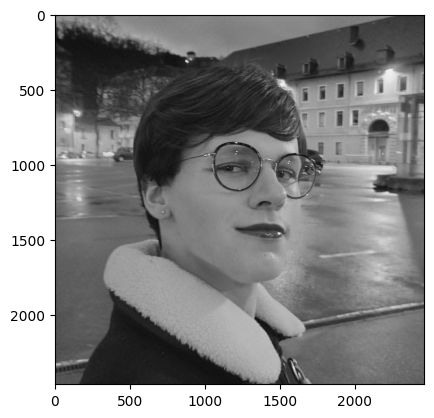

In [88]:
approx = U @ Sigma @ Vt

fig, ax = plt.subplots()
ax.imshow(approx, cmap="gray")

Je vais à présent appliquer cette même méthode pour obtenir une image en couleur. Il ne s’agit pas de la façon la plus efficace de faire (qui sera, elle, abordée juste après)

In [89]:
# RGB : 0 red, 1 green, 2 blue
red_array = img_array[:, :, 0]
green_array = img_array[:, :, 1]
blue_array = img_array[:, :, 2]

U_red, s_red, Vt_red = np.linalg.svd(red_array)
U_green, s_green, Vt_green = np.linalg.svd(green_array)
U_blue, s_blue, Vt_blue = np.linalg.svd(blue_array)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.07069266..1.0928351].


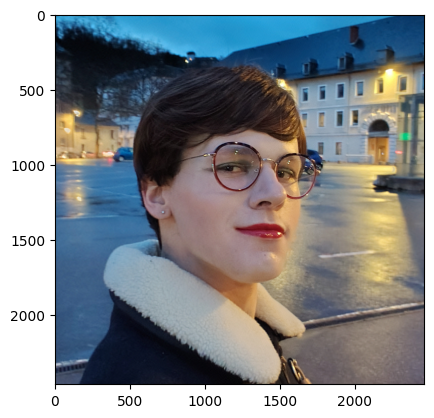

In [90]:
Sigma_red = np.diag(s_red)
Sigma_green = np.diag(s_green)
Sigma_blue = np.diag(s_blue)

k = 200
red_approx = U_red @ Sigma_red[:, :k] @ Vt_red[:k, :]
green_approx = U_green @ Sigma_green[:, :k] @ Vt_green[:k, :]
blue_approx = U_blue @ Sigma_blue[:, :k] @ Vt_blue[:k, :]

compressed_img = np.stack([red_approx, green_approx, blue_approx], axis=2)

fig, ax = plt.subplots()
ax.imshow(compressed_img) # Pas besoin de rescale !

À présent, nous allons procéder de façon plus efficace. La fonction np.linalg.svd de numpy accepte des matrices de dimension supérieure à 2, mais s’attend à recevoir une matrice de la forme (n, M, N) ; n étant le nombre de matrices de taille MxN contenues dans l’array qu’on lui donne.

Il faut donc transposer la matrice img_array avant de lui appliquer la fonction svd().

In [91]:
print(img_array.shape)
img_array_transposed = np.transpose(img_array, (2, 0, 1))
print(img_array_transposed.shape)

(2464, 2464, 3)
(3, 2464, 2464)


In [92]:
U, s, Vt = np.linalg.svd(img_array_transposed)
print(U.shape)
print(s.shape)
print(Vt.shape)

(3, 2464, 2464)
(3, 2464)
(3, 2464, 2464)


Nous pouvons à présent réduire les array s et Vt

In [93]:
k = 150

U = U[..., :k]
s = s[..., :k]
Vt = Vt[..., :k, :]

print(U.shape)
print(s.shape)
print(Vt.shape)

(3, 2464, 150)
(3, 150)
(3, 150, 2464)


Appliquons la même transformation à Sigma, en itérant une fois par canal RGB.

In [94]:
s.shape

(3, 150)

In [95]:
Sigma = np.zeros((3, k, k))
for RGB_channel in range(3):
    Sigma[RGB_channel] = np.diag(s[RGB_channel])

print(U.shape)
print(Sigma.shape)
print(Vt.shape)

reconstructed = U @ Sigma @ Vt

(3, 2464, 150)
(3, 150, 150)
(3, 150, 2464)


La matrice obtenue possède des valeurs légèrement hors de la borne [0;1], à cause des erreurs d’approximation. Résolvons cela avec la fonction clip. Et voilà : nous avons compressé notre image ! 😁

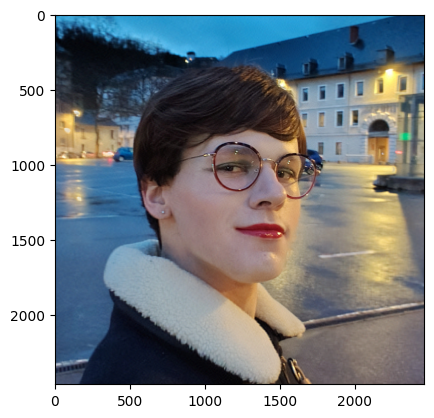

In [96]:
reconstructed_img = np.transpose(reconstructed, (1, 2, 0))
reconstructed_img = np.clip(reconstructed_img, 0, 1)

fig, ax = plt.subplots()
ax.imshow(reconstructed_img)

In [97]:
compressed_size = U.size + s.size + Vt.size
percentage_size_reduction =  (1 - compressed_size/img_array.size) * 100
print(f"La taille du fichier a été réduite de {percentage_size_reduction:.2f}%")

La taille du fichier a été réduite de 87.82%
